El algoritmo Devroye genera variables aleatorias (x,y) a partir de la distribución exponencial bivariada de Marshall-Olkin con parámetros $\lambda_1, \lambda_2 y \lambda_{12}$.\
Pasos
1. Generar tres variables uniformes $r,s,t$ independientes uniformes $(0,1)$
2. $x=min(\frac{-ln(r)}{\lambda_1},\frac{-ln(t)}{\lambda_{1,2}})$, $y=min(\frac{-ln(s)}{\lambda_2},\frac{-ln(t)}{\lambda_{1,2}})$\
3. Con $u=exp(-(\lambda_1+\lambda_{1,2})x), v=exp(-(\lambda_1+\lambda_{1,2})y)$
4. Asignar pares $(u,v)$

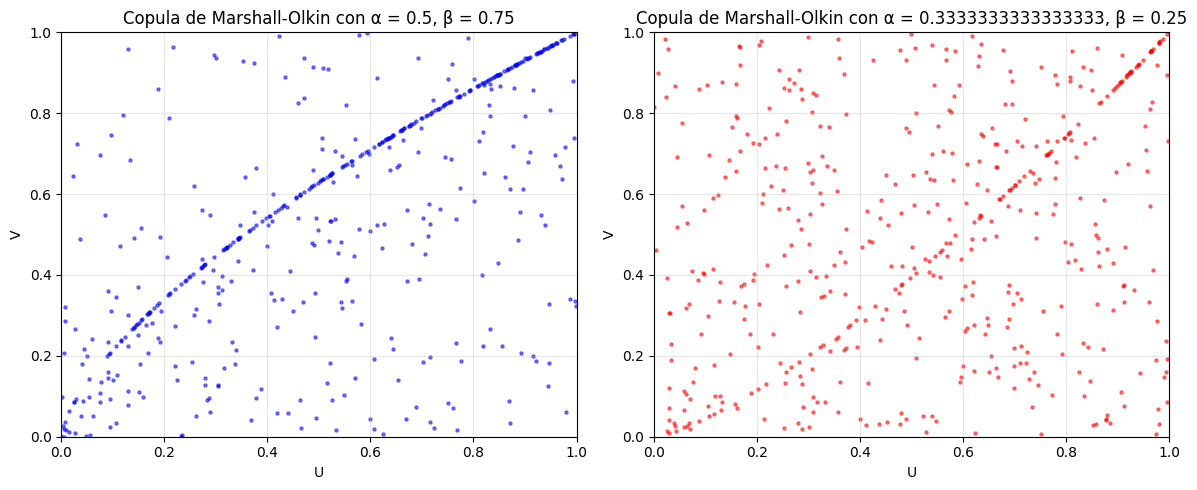

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def generar_copula_marshall_olkin(n, alpha, beta):
    '''
    α=λ_12/(λ_1+λ_12) y β=λ_12/(λ_2+λ_12)
    λ1=λ_12(1/α-1) y λ2=λ_12(1/β-1)
    '''
    lambda12 = 1.0  #Valor arbitrario (no afecta)
    lambda1 = lambda12 * (1/alpha - 1)
    lambda2 = lambda12 * (1/beta - 1)

    r = np.random.uniform(0, 1, n)
    s = np.random.uniform(0, 1, n)
    t = np.random.uniform(0, 1, n)

    x = np.minimum(-np.log(r)/lambda1, -np.log(t)/lambda12)
    y = np.minimum(-np.log(s)/lambda2, -np.log(t)/lambda12)

    # Cópula (U,V)
    u = np.exp(-(lambda1 + lambda12) * x)
    v = np.exp(-(lambda2 + lambda12) * y)

    return u, v


casos = [(1/2, 3/4), (1/3, 1/4)] #Casos donde (α,β)=(1/2,3/4) y (α,β)=(1/3,1/4)
colores = ['blue', 'red']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, ((alpha, beta), color) in enumerate(zip(casos, colores)):
    u, v = generar_copula_marshall_olkin(500, alpha, beta)
    axes[i].scatter(u, v, alpha=0.5, s=5, color=color)
    axes[i].set_xlabel('U')
    axes[i].set_ylabel('V')
    axes[i].set_title(f'Copula de Marshall-Olkin con α = {alpha}, β = {beta}')
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()